# Results NVV-Pipeline Evaluation Experiment - Full-GT and Part-GT
- yml: environment.yml
- env: nvv_isolation_pipeline
- last updated: 05.04.2026


## Setup
- Imports
- Config

In [1]:
#Setup
import os
import sys
from pathlib import Path

project_root = Path(os.getcwd()).parent
sys.path.append(str(project_root))

import pandas as pd
import matplotlib.pyplot as plt

from config.load_config import load_config
from config.path_factory import print_paths

from evaluation.analysis_loader import load_and_compare_workspaces

from evaluation.analysis_tables import build_rq1_capability_tables

from evaluation.analysis_tables import (
    build_setting_summary_table,
    build_best_all_screened_values_matrix,
    build_derivative_matrix,
    build_top_k_runs_table
)
from evaluation.analysis_plots import (
    plot_setting_overview,
    plot_derivative_group_comparison,
    plot_top_k_runs_per_setting,
)

cfg_path_nvs_full_gt = project_root / "experiments" / "screening" / "config_param_screening_nvs38k_full_gt.yaml"
cfg_path_nvs_part_gt = project_root / "experiments" / "screening" / "config_param_screening_nvs38k_part_gt.yaml"
cfg_path_vocal_part_gt = project_root / "experiments" / "screening" / "config_param_screening_vocal_part_gt.yaml"


config = load_config(cfg_path_nvs_full_gt)
print_paths(cfg_path_nvs_full_gt)


NVV PATH CONFIG PRINT

[PROJECT]
  cfg_path:       /home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/experiments/screening/config_param_screening_nvs38k_full_gt.yaml
  project_root:   /home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline
  raw_root:       /home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/raw
  processed_root: /home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/processed/NVS-38K_EN_10_categories

[PIPELINE WORKSPACES]

  - NVS-38K_EN_10_categories
      input_dir:  /home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/raw/experiment_parameter_screening/NVS-38K_EN_10_categories
      workspace:  /home/entraID/mareike.focken@study.hs-duesseldorf.de/thesis/repos/nvv-isolation-pipeline/data/processed/NVS-38K_EN_10_categories/NVS-38K_EN_10_categories
      evaluation: /home/ent

## Collect Pipeline Evaluation Experiment Results 
- Experiment specs for comparison


In [22]:
# specification of full run evaluation experiments to load and compare (all settings)
specs = [
    {
        "label": "NVS-38K_EN_10_categories | full_gt",
        "cfg_path": cfg_path_nvs_full_gt,
        "dataset_name": "NVS-38K_EN_10_categories",
        "mode": "full_gt",
    },
    {
        "label": "NVS-38K_EN_10_categories | part_gt",
        "cfg_path": cfg_path_nvs_part_gt,
        "dataset_name": "NVS-38K_EN_10_categories",
        "mode": "part_gt",
    },
        {
        "label": "VOCAL_10_categories | part_gt",
        "cfg_path": cfg_path_vocal_part_gt,
        "dataset_name": "VOCAL_10_categories",
        "mode": "part_gt",
    },
]

analysis_bundle = load_and_compare_workspaces(
    specs=specs,
    param_names=[],
    param_pairs=[],
)

bundles_by_spec = analysis_bundle["bundles_by_spec"]
views_by_spec = analysis_bundle["views_by_spec"]
views = analysis_bundle["combined_views"]
setting_order = analysis_bundle["setting_order"]


In [23]:
bundles_by_spec.keys()

dict_keys(['NVS-38K_EN_10_categories | full_gt', 'NVS-38K_EN_10_categories | part_gt', 'VOCAL_10_categories | part_gt'])

## RQ1 Pipeline Capability

In [24]:

# RQ1 Pipeline Capability
# --- collect RQ1 tables from the loaded settings ---
rq1_all = pd.concat(
    [
        bundle["results"]["rq1"]
        for bundle in analysis_bundle["bundles_by_spec"].values()
    ],
    ignore_index=True,
)

rq1_tables = build_rq1_capability_tables(rq1_all)

print("RQ1 Capability Table (Full-GT):")
display(rq1_tables["full_gt"])

print("RQ1 Capability Table (Part-GT):")
display(rq1_tables["part_gt"])




RQ1 Capability Table (Full-GT):


,Setting,System,F1,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,NVS-38K_EN_10_categories | full_gt,Baseline,0.333333,0.4,0.3562,0.3562,0.7
1,NVS-38K_EN_10_categories | full_gt,Best Selected Set,0.500000,0.5,0.4081,0.4081,0.4
2,NVS-38K_EN_10_categories | full_gt,Δ vs Baseline,0.166667,0.1,0.0519,0.0519,-0.3


RQ1 Capability Table (Part-GT):


,Setting,System,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,NVS-38K_EN_10_categories | part_gt,Baseline,0.400000,0.356200,0.35620,0.7000
1,NVS-38K_EN_10_categories | part_gt,Best Selected Set,0.500000,0.408100,0.40810,1.2000
2,NVS-38K_EN_10_categories | part_gt,Δ vs Baseline,0.100000,0.051900,0.05190,0.5000
3,VOCAL_10_categories | part_gt,Baseline,0.216667,0.200733,0.28105,1.8625
4,VOCAL_10_categories | part_gt,Best Selected Set,0.229167,0.212621,0.37280,2.5500
5,VOCAL_10_categories | part_gt,Δ vs Baseline,0.012500,0.011887,0.09175,0.6875


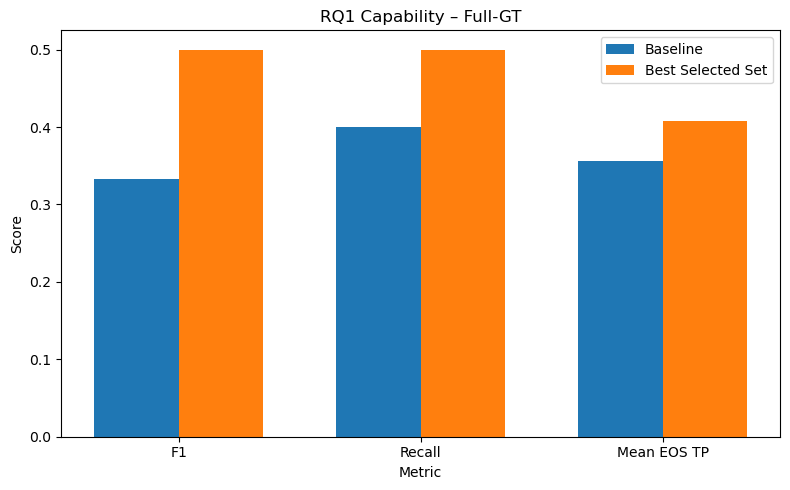

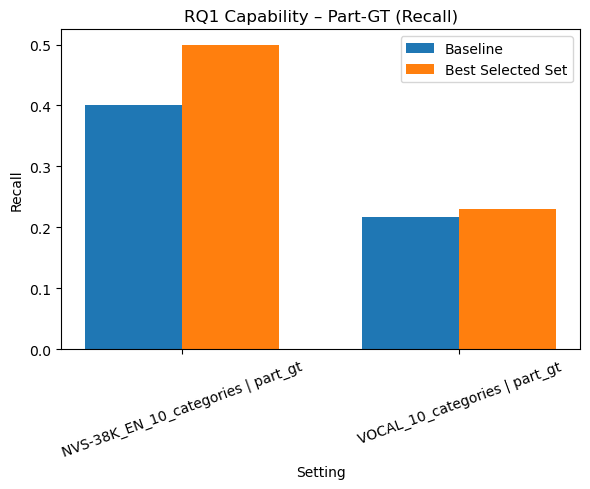

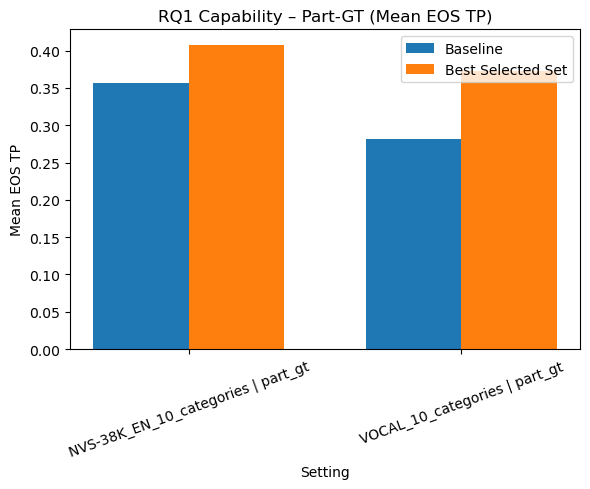

In [25]:
from evaluation.rq_plots import plot_rq1_full_gt_grouped_bars, plot_rq1_part_gt_grouped_bars

fig = plot_rq1_full_gt_grouped_bars(rq1_tables["full_gt"])
plt.show()

fig = plot_rq1_part_gt_grouped_bars(rq1_tables["part_gt"], metric="Recall", setting_order=setting_order)
plt.show()

fig = plot_rq1_part_gt_grouped_bars(rq1_tables["part_gt"], metric="Mean EOS TP", setting_order=setting_order)
plt.show()

## RQ2 Ranking Configuration: Single best

In [26]:
from evaluation.analysis_tables import build_rq2a_single_ranking_tables

rq2a_single_all = pd.concat(
    [
        bundle["results"]["rq2a_single"]
        for bundle in analysis_bundle["bundles_by_spec"].values()
    ],
    ignore_index=True,
)

rq2a_single_tables = build_rq2a_single_ranking_tables(
    rq2a_single_all,
    top_k=10,
)

print("RQ2a Single Ranking Tables:")
for setting_name, df_table in rq2a_single_tables.items():
    print(f"\n=== {setting_name} ===")
    display(df_table)

RQ2a Single Ranking Tables:

=== NVS-38K_EN_10_categories | full_gt ===


,Rank,VAD Mask,ASR Audio Input,F1,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,1,std_vocals_norm,std_vocals_norm,0.500000,0.5,0.4081,0.4081,0.4
1,2,std_vocals,std_vocals_norm,0.500000,0.5,0.4081,0.4081,0.5
2,3,original,std_vocals,0.366667,0.4,0.3143,0.3143,0.7
3,4,original,std_vocals_norm,0.366667,0.4,0.3130,0.3130,0.7
4,5,std,std_vocals_norm,0.366667,0.4,0.3130,0.3130,0.7
5,6,original,original,0.333333,0.4,0.3562,0.3562,0.7
6,7,original,std,0.333333,0.4,0.3562,0.3562,0.7
7,8,std_vocals,std_vocals,0.266667,0.3,0.2336,0.2336,0.8
8,9,std_vocals,original,0.233333,0.3,0.2768,0.2768,1.0
9,10,std_vocals,std,0.233333,0.3,0.2768,0.2768,1.0



=== NVS-38K_EN_10_categories | part_gt ===


,Rank,VAD Mask,ASR Audio Input,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,1,std_vocals_norm,std_vocals_norm,0.5,0.4081,0.4081,0.4
1,2,std_vocals,std_vocals_norm,0.5,0.4081,0.4081,0.5
2,3,original,original,0.4,0.3562,0.3562,0.7
3,4,original,std,0.4,0.3562,0.3562,0.7
4,5,original,std_vocals,0.4,0.3143,0.3143,0.7
5,6,original,std_vocals_norm,0.4,0.3130,0.3130,0.7
6,7,std,std_vocals_norm,0.4,0.3130,0.3130,0.7
7,8,std_vocals_norm,original,0.3,0.2768,0.2768,0.9
8,9,std_vocals_norm,std,0.3,0.2768,0.2768,0.9
9,10,std_vocals,original,0.3,0.2768,0.2768,1.0



=== VOCAL_10_categories | part_gt ===


,Rank,VAD Mask,ASR Audio Input,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,1,std_vocals_norm,std,0.229167,0.212621,0.37280,2.454167
1,2,std_vocals,std,0.229167,0.212621,0.37280,2.512500
2,3,std_vocals_norm,original,0.229167,0.211854,0.37165,2.504167
3,4,std_vocals,original,0.229167,0.211854,0.37165,2.512500
4,5,std,std,0.216667,0.201233,0.28170,1.712500
5,6,original,std,0.216667,0.200733,0.28105,1.812500
6,7,original,original,0.216667,0.200733,0.28105,1.862500
7,8,std,original,0.216667,0.200467,0.28055,1.712500
8,9,std_vocals_norm,std_background_norm,0.195833,0.179525,0.36150,2.625000
9,10,std_vocals,std_background_norm,0.195833,0.179525,0.36150,2.633333


In [27]:
#toDo: check creation of columns, one of them is wrong
rq2a_single_all[[
    "setting",
    "macro_mean_dice_eos_recall",
    "macro_mean_mean_dice_eos_tp",
]].head(20)

,setting,macro_mean_dice_eos_recall,macro_mean_mean_dice_eos_tp
0,NVS-38K_EN_10_categories | full_gt,0.4081,0.4081
1,NVS-38K_EN_10_categories | full_gt,0.4081,0.4081
2,NVS-38K_EN_10_categories | full_gt,0.3143,0.3143
3,NVS-38K_EN_10_categories | full_gt,0.3130,0.3130
4,NVS-38K_EN_10_categories | full_gt,0.3130,0.3130
5,NVS-38K_EN_10_categories | full_gt,0.3562,0.3562
6,NVS-38K_EN_10_categories | full_gt,0.3562,0.3562
7,NVS-38K_EN_10_categories | full_gt,0.2336,0.2336
8,NVS-38K_EN_10_categories | full_gt,0.2768,0.2768
9,NVS-38K_EN_10_categories | full_gt,0.2768,0.2768


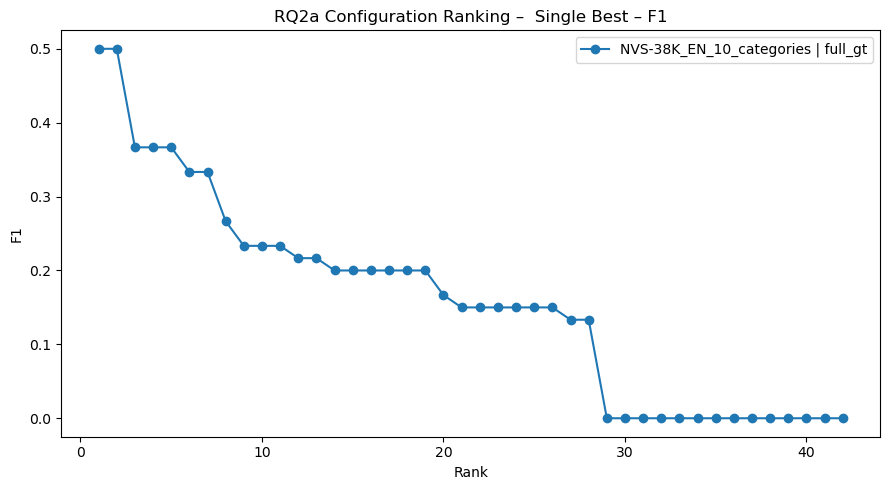

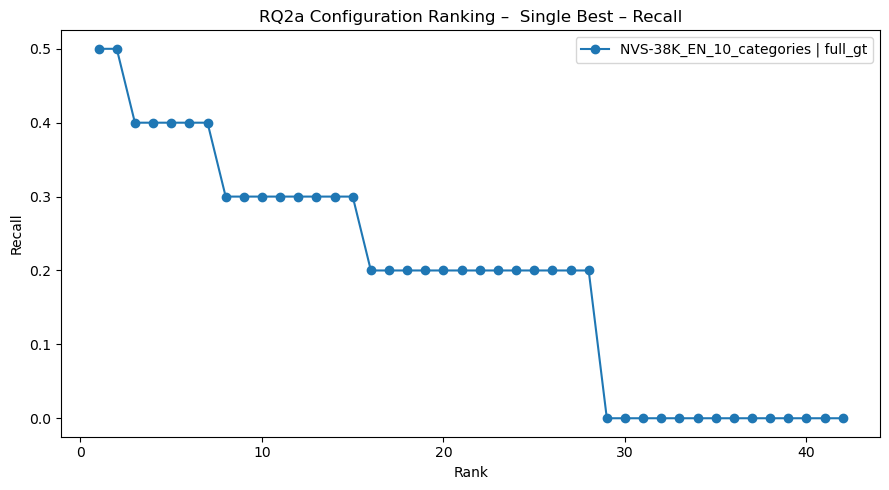

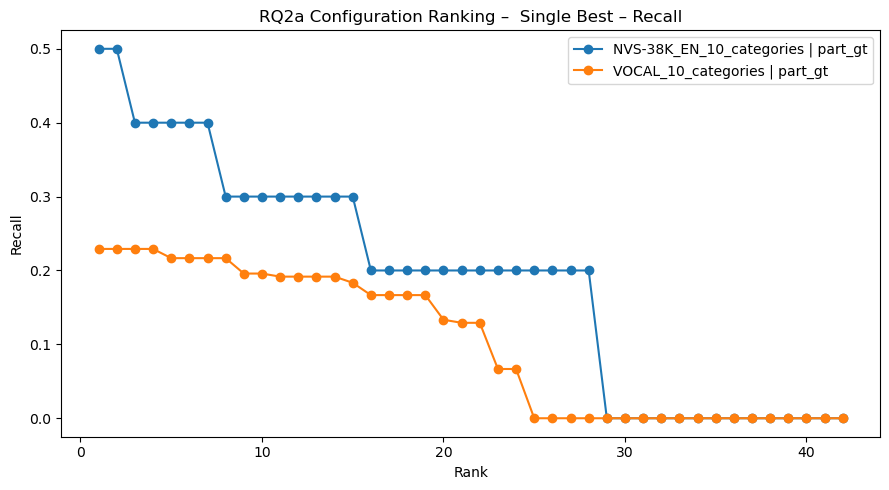

In [28]:

from evaluation.rq_plots import plot_rq2a_rank_vs_score

fig = plot_rq2a_rank_vs_score(
    rq2a_single_all,
    mode="full_gt",
    score_col="macro_mean_f1",
    top_k=42,
    setting_order=setting_order,
)
plt.show()

fig = plot_rq2a_rank_vs_score(
    rq2a_single_all,
    mode="full_gt",
    score_col="macro_mean_recall",
    top_k=42,
    setting_order=setting_order,
)
plt.show()

fig = plot_rq2a_rank_vs_score(
    rq2a_single_all,
    mode="part_gt",
    score_col="macro_mean_recall",
    top_k=42,
    setting_order=setting_order,
)
plt.show()


## RQ2 Configuration Combination: Selected Set

In [29]:
from evaluation.analysis_tables import build_rq2a_selected_set_tables

rq2a_selected_all = pd.concat(
    [
        bundle["results"]["rq2a_selected_set"]
        for bundle in analysis_bundle["bundles_by_spec"].values()
    ],
    ignore_index=True,
)

rq2a_selected_tables = build_rq2a_selected_set_tables(
    rq2a_single_all,
    rq2a_selected_all,
)

print("RQ2a Selected Set Tables:")
for setting_name, df_table in rq2a_selected_tables.items():
    print(f"\n=== {setting_name} ===")
    display(df_table)

RQ2a Selected Set Tables:

=== NVS-38K_EN_10_categories | full_gt ===


/tmp/ipykernel_101471/244519257.py:3: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  rq2a_selected_all = pd.concat(
/tmp/ipykernel_101471/244519257.py:3: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  rq2a_selected_all = pd.concat(


,Setting,System,k,Config / Selected Set,F1,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,NVS-38K_EN_10_categories | full_gt,Best Single,1,std_vocals_norm + std_vocals_norm,0.5,0.5,0.4081,0.4081,0.4
1,NVS-38K_EN_10_categories | full_gt,Best Selected Set,1,"[""std_vocals_norm_vad_std_vocals_norm_asr_nlp_...",0.5,0.5,0.4081,0.4081,0.4
2,NVS-38K_EN_10_categories | full_gt,Δ vs Best Single,0,None,0.0,0.0,0.0000,0.0000,0.0



=== NVS-38K_EN_10_categories | part_gt ===


,Setting,System,k,Config / Selected Set,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,NVS-38K_EN_10_categories | part_gt,Best Single,1,std_vocals_norm + std_vocals_norm,0.5,0.4081,0.4081,0.4
1,NVS-38K_EN_10_categories | part_gt,Best Selected Set,3,"[""std_vocals_norm_vad_std_vocals_norm_asr_nlp_...",0.5,0.4081,0.4081,1.2
2,NVS-38K_EN_10_categories | part_gt,Δ vs Best Single,2,None,0.0,0.0000,0.0000,0.8



=== VOCAL_10_categories | part_gt ===


,Setting,System,k,Config / Selected Set,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,VOCAL_10_categories | part_gt,Best Single,1,std_vocals_norm + std,0.229167,0.212621,0.3728,2.454167
1,VOCAL_10_categories | part_gt,Best Selected Set,2,"[""std_vocals_norm_vad_std_asr_nlp_nvv"", ""std_v...",0.229167,0.212621,0.3728,2.550000
2,VOCAL_10_categories | part_gt,Δ vs Best Single,1,None,0.000000,0.000000,0.0000,0.095833


## RQ2 Audio Derivative Aggregation

In [30]:
# RQ2 Audio Derivative Aggregation - Just for inspection, not for final presentation. ToDo: update artifact with insertion rate and remove precision and f1 for part_gt
# Keep derivative matrices separated by metric / mode
derivative_matrix_f1 = build_derivative_matrix(
    views["derivative_comparison"][
        views["derivative_comparison"]["mode"] == "full_gt"
    ],
    value_col="macro_mean_f1", #toDo: also recall and dice
)

derivative_matrix_recall = build_derivative_matrix(
    views["derivative_comparison"][
        views["derivative_comparison"]["mode"] == "part_gt"
    ],
    value_col="macro_mean_recall", #toDo also eos and eos_tp and insertion_rate
)

print("\nDerivative Matrix (F1, full_gt):")
display(derivative_matrix_f1)
print("\nDerivative Matrix (Recall, part_gt):")
display(derivative_matrix_recall)




Derivative Matrix (F1, full_gt):


setting,audio_derivative_group,NVS-38K_EN_10_categories | full_gt
0,all_derivatives,0.159524
1,background_like,0.092857
2,original_like,0.159524
3,vocals_like,0.226190



Derivative Matrix (Recall, part_gt):


setting,audio_derivative_group,NVS-38K_EN_10_categories | part_gt,VOCAL_10_categories | part_gt
0,all_derivatives,0.190476,0.102778
1,background_like,0.128571,0.078571
2,original_like,0.200000,0.127381
3,vocals_like,0.242857,0.102381


In [31]:
# RQ2b Audio Derivative Aggregation - Group Comparison (Thesis Tables)
from evaluation.analysis_tables import build_rq2b_derivative_tables
## RQ2b Audio Derivative Aggregation

rq2b_tables = build_rq2b_derivative_tables(views["derivative_comparison"])

print("RQ2b Audio Derivative Table (Full-GT):")
display(rq2b_tables["full_gt"])

print("RQ2b Audio Derivative Table (Part-GT):")
display(rq2b_tables["part_gt"])

RQ2b Audio Derivative Table (Full-GT):


,Setting,Audio Derivative,F1,Recall,EOS Recall,Mean EOS TP,Insertion Rate,Best Config (VAD Mask + ASR Audio Input)
0,NVS-38K_EN_10_categories | full_gt,original_like,0.159524,0.200000,0.181114,0.181114,0.557143,original + original
1,NVS-38K_EN_10_categories | full_gt,vocals_like,0.226190,0.242857,0.194229,0.194229,0.435714,std_vocals_norm + std_vocals_norm
2,NVS-38K_EN_10_categories | full_gt,background_like,0.092857,0.128571,0.108500,0.108500,0.664286,std_vocals_norm + std_background_norm
3,NVS-38K_EN_10_categories | full_gt,all_derivatives,0.159524,0.190476,0.161281,0.161281,0.552381,std_vocals_norm + std_vocals_norm


RQ2b Audio Derivative Table (Part-GT):


,Setting,Audio Derivative,Recall,EOS Recall,Mean EOS TP,Insertion Rate,Best Config (VAD Mask + ASR Audio Input)
0,NVS-38K_EN_10_categories | part_gt,original_like,0.200000,0.181114,0.181114,0.557143,original + original
1,VOCAL_10_categories | part_gt,original_like,0.127381,0.118008,0.186661,1.349107,std_vocals_norm + std
2,NVS-38K_EN_10_categories | part_gt,vocals_like,0.242857,0.194229,0.194229,0.435714,std_vocals_norm + std_vocals_norm
3,VOCAL_10_categories | part_gt,vocals_like,0.102381,0.092401,0.128193,1.299405,std_vocals + std_vocals_norm
4,NVS-38K_EN_10_categories | part_gt,background_like,0.128571,0.108500,0.108500,0.664286,std_vocals_norm + std_background_norm
5,VOCAL_10_categories | part_gt,background_like,0.078571,0.072904,0.138739,1.632738,std_vocals_norm + std_background_norm
6,NVS-38K_EN_10_categories | part_gt,all_derivatives,0.190476,0.161281,0.161281,0.552381,std_vocals_norm + std_vocals_norm
7,VOCAL_10_categories | part_gt,all_derivatives,0.102778,0.094438,0.151198,1.427083,std_vocals_norm + std


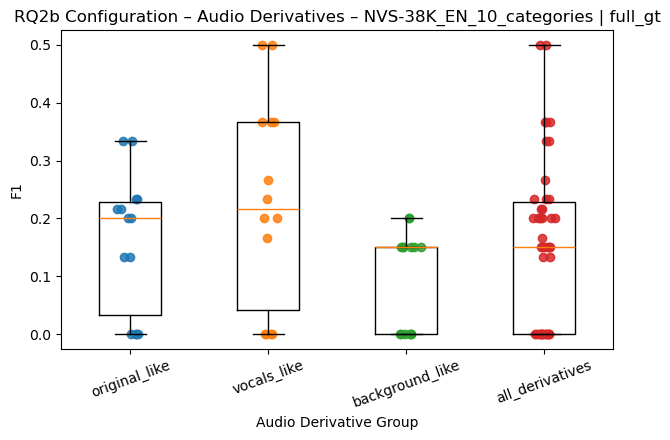

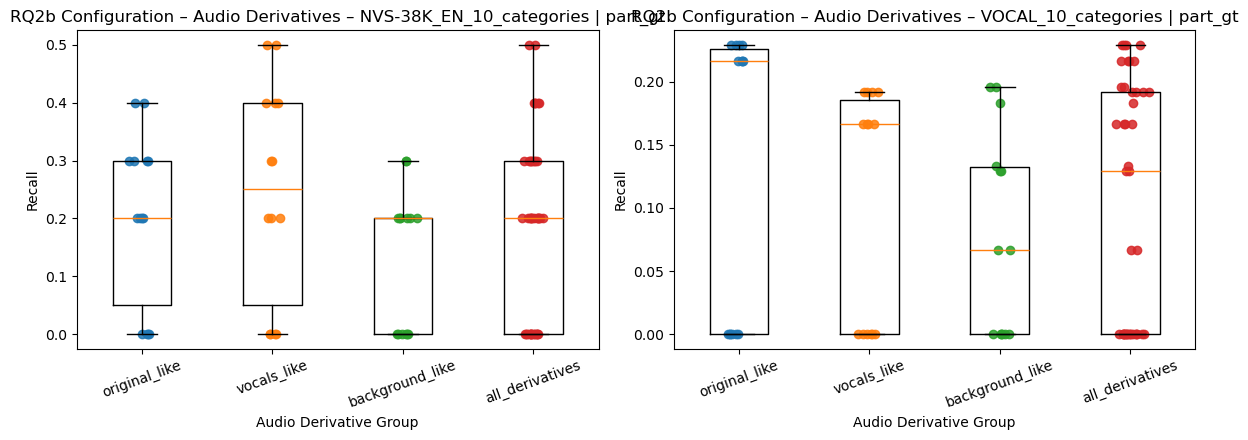

In [32]:
from evaluation.rq_plots import plot_rq2b_boxplot_with_points
fig = plot_rq2b_boxplot_with_points(
    rq2a_single_all,
    mode="full_gt",
    score_col="macro_mean_f1",
    top_k=None,
    setting_order=setting_order,
)
plt.show()

fig = plot_rq2b_boxplot_with_points(
    rq2a_single_all,
    mode="part_gt",
    score_col="macro_mean_recall",
    top_k=None,
    setting_order=setting_order,
)
plt.show()

## RQ2b Inspection of top 2

In [33]:
from evaluation.analysis_tables import inspect_top_n_rq2a_configs_by_group

df_top2_derivatives_full = inspect_top_n_rq2a_configs_by_group(
    rq2a_single_all,
    mode="full_gt",
    group_by="audio_derivative_group",
    top_n=2,
    setting_order=setting_order,
)
display(df_top2_derivatives_full)

df_top2_derivatives_part = inspect_top_n_rq2a_configs_by_group(
    rq2a_single_all,
    mode="part_gt",
    group_by="audio_derivative_group",
    top_n=2,
    setting_order=setting_order,
)
display(df_top2_derivatives_part)

,setting,audio_derivative_group,combo_key,vad_mask,asr_audio_in,macro_mean_f1,macro_mean_recall,macro_mean_dice_eos_recall,macro_mean_mean_dice_eos_tp,macro_mean_insertion_rate,rank_within_run
0,NVS-38K_EN_10_categories | full_gt,background_like,std_vocals_norm_vad_std_background_norm_asr_nl...,std_vocals_norm,std_background_norm,0.200000,0.3,0.2612,0.2612,0.7,14
1,NVS-38K_EN_10_categories | full_gt,background_like,std_vocals_vad_std_background_norm_asr_nlp_nvv,std_vocals,std_background_norm,0.200000,0.3,0.2612,0.2612,0.8,15
2,NVS-38K_EN_10_categories | full_gt,original_like,original_vad_original_asr_nlp_nvv,original,original,0.333333,0.4,0.3562,0.3562,0.7,6
3,NVS-38K_EN_10_categories | full_gt,original_like,original_vad_std_asr_nlp_nvv,original,std,0.333333,0.4,0.3562,0.3562,0.7,7
4,NVS-38K_EN_10_categories | full_gt,vocals_like,std_vocals_norm_vad_std_vocals_norm_asr_nlp_nvv,std_vocals_norm,std_vocals_norm,0.500000,0.5,0.4081,0.4081,0.4,1
5,NVS-38K_EN_10_categories | full_gt,vocals_like,std_vocals_vad_std_vocals_norm_asr_nlp_nvv,std_vocals,std_vocals_norm,0.500000,0.5,0.4081,0.4081,0.5,2


,setting,audio_derivative_group,combo_key,vad_mask,asr_audio_in,macro_mean_recall,macro_mean_dice_eos_recall,macro_mean_mean_dice_eos_tp,macro_mean_insertion_rate,rank_within_run
0,NVS-38K_EN_10_categories | part_gt,background_like,std_vocals_norm_vad_std_background_norm_asr_nl...,std_vocals_norm,std_background_norm,0.300000,0.261200,0.2612,0.700000,12
1,NVS-38K_EN_10_categories | part_gt,background_like,std_vocals_vad_std_background_norm_asr_nlp_nvv,std_vocals,std_background_norm,0.300000,0.261200,0.2612,0.800000,13
2,NVS-38K_EN_10_categories | part_gt,original_like,original_vad_original_asr_nlp_nvv,original,original,0.400000,0.356200,0.3562,0.700000,3
3,NVS-38K_EN_10_categories | part_gt,original_like,original_vad_std_asr_nlp_nvv,original,std,0.400000,0.356200,0.3562,0.700000,4
4,NVS-38K_EN_10_categories | part_gt,vocals_like,std_vocals_norm_vad_std_vocals_norm_asr_nlp_nvv,std_vocals_norm,std_vocals_norm,0.500000,0.408100,0.4081,0.400000,1
5,NVS-38K_EN_10_categories | part_gt,vocals_like,std_vocals_vad_std_vocals_norm_asr_nlp_nvv,std_vocals,std_vocals_norm,0.500000,0.408100,0.4081,0.500000,2
6,VOCAL_10_categories | part_gt,background_like,std_vocals_norm_vad_std_background_norm_asr_nl...,std_vocals_norm,std_background_norm,0.195833,0.179525,0.3615,2.625000,9
7,VOCAL_10_categories | part_gt,background_like,std_vocals_vad_std_background_norm_asr_nlp_nvv,std_vocals,std_background_norm,0.195833,0.179525,0.3615,2.633333,10
8,VOCAL_10_categories | part_gt,original_like,std_vocals_norm_vad_std_asr_nlp_nvv,std_vocals_norm,std,0.229167,0.212621,0.3728,2.454167,1
9,VOCAL_10_categories | part_gt,original_like,std_vocals_vad_std_asr_nlp_nvv,std_vocals,std,0.229167,0.212621,0.3728,2.512500,2


## Configuration VAD Mask Inspection

In [34]:
from evaluation.analysis_tables import build_rq2b_vad_mask_tables

rq2b_vad_tables = build_rq2b_vad_mask_tables(
    rq2a_single_all,
    setting_order=setting_order,
)

display(rq2b_vad_tables["full_gt"])
display(rq2b_vad_tables["part_gt"])

,Setting,VAD Mask,F1,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,NVS-38K_EN_10_categories | full_gt,no,0.133333,0.133333,0.120467,0.120467,0.183333
1,NVS-38K_EN_10_categories | full_gt,original,0.283333,0.333333,0.278650,0.278650,0.833333
2,NVS-38K_EN_10_categories | full_gt,std,0.183333,0.233333,0.188983,0.188983,0.983333
3,NVS-38K_EN_10_categories | full_gt,std_background,0.000000,0.000000,0.000000,0.000000,0.033333
4,NVS-38K_EN_10_categories | full_gt,std_background_norm,0.000000,0.000000,0.000000,0.000000,0.133333
5,NVS-38K_EN_10_categories | full_gt,std_vocals,0.263889,0.316667,0.270433,0.270433,0.883333
6,NVS-38K_EN_10_categories | full_gt,std_vocals_norm,0.252778,0.316667,0.270433,0.270433,0.816667


,Setting,VAD Mask,Recall,EOS Recall,Mean EOS TP,Insertion Rate
0,NVS-38K_EN_10_categories | part_gt,no,0.133333,0.120467,0.120467,0.183333
1,NVS-38K_EN_10_categories | part_gt,original,0.333333,0.278650,0.278650,0.833333
2,NVS-38K_EN_10_categories | part_gt,std,0.233333,0.188983,0.188983,0.983333
3,NVS-38K_EN_10_categories | part_gt,std_background,0.000000,0.000000,0.000000,0.033333
4,NVS-38K_EN_10_categories | part_gt,std_background_norm,0.000000,0.000000,0.000000,0.133333
5,NVS-38K_EN_10_categories | part_gt,std_vocals,0.316667,0.270433,0.270433,0.883333
6,NVS-38K_EN_10_categories | part_gt,std_vocals_norm,0.316667,0.270433,0.270433,0.816667
7,VOCAL_10_categories | part_gt,no,0.000000,0.000000,0.000000,0.518750
8,VOCAL_10_categories | part_gt,original,0.161111,0.147344,0.199808,2.073611
9,VOCAL_10_categories | part_gt,std,0.169444,0.156111,0.217058,2.000000


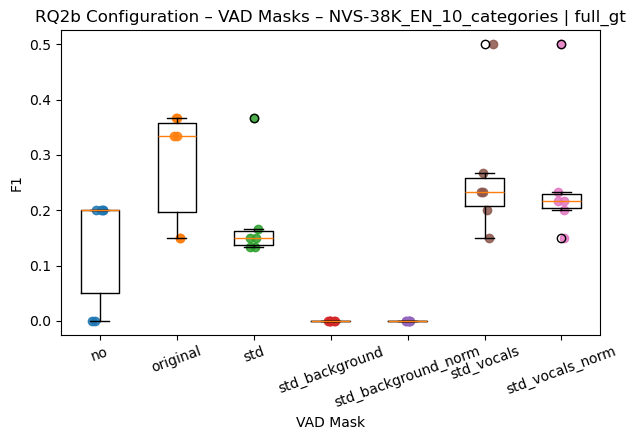

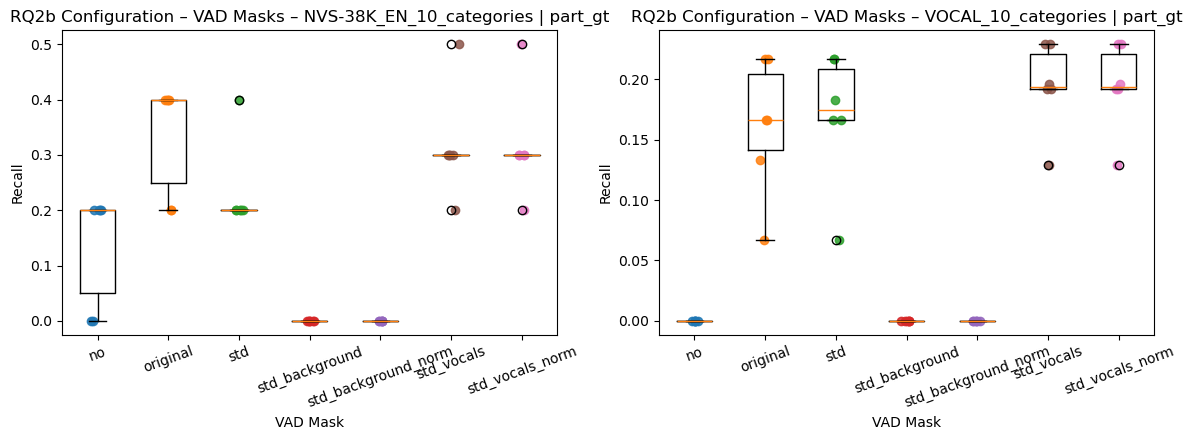

In [35]:
from evaluation.rq_plots import plot_rq2b_vad_mask_boxplot_with_points

fig = plot_rq2b_vad_mask_boxplot_with_points(
    rq2a_single_all,
    mode="full_gt",
    score_col="macro_mean_f1",
    top_k=None,
    setting_order=setting_order,
)
plt.show()

fig = plot_rq2b_vad_mask_boxplot_with_points(
    rq2a_single_all,
    mode="part_gt",
    score_col="macro_mean_recall",
    top_k=None,
    setting_order=setting_order,
)
plt.show()

In [36]:
df_top2_vad_full = inspect_top_n_rq2a_configs_by_group(
    rq2a_single_all,
    mode="full_gt",
    group_by="vad_mask",
    top_n=2,
    setting_order=setting_order,
)
display(df_top2_vad_full)

df_top2_vad_part = inspect_top_n_rq2a_configs_by_group(
    rq2a_single_all,
    mode="part_gt",
    group_by="vad_mask",
    top_n=2,
    setting_order=setting_order,
)
display(df_top2_vad_part)

,setting,vad_mask,combo_key,vad_mask,asr_audio_in,macro_mean_f1,macro_mean_recall,macro_mean_dice_eos_recall,macro_mean_mean_dice_eos_tp,macro_mean_insertion_rate,rank_within_run
0,NVS-38K_EN_10_categories | full_gt,no,no_vad_std_vocals_norm_asr_nlp_nvv,no,std_vocals_norm,0.200000,0.2,0.1807,0.1807,0.2,16
1,NVS-38K_EN_10_categories | full_gt,no,no_vad_original_asr_nlp_nvv,no,original,0.200000,0.2,0.1807,0.1807,0.3,17
2,NVS-38K_EN_10_categories | full_gt,original,original_vad_std_vocals_asr_nlp_nvv,original,std_vocals,0.366667,0.4,0.3143,0.3143,0.7,3
3,NVS-38K_EN_10_categories | full_gt,original,original_vad_std_vocals_norm_asr_nlp_nvv,original,std_vocals_norm,0.366667,0.4,0.3130,0.3130,0.7,4
4,NVS-38K_EN_10_categories | full_gt,std,std_vad_std_vocals_norm_asr_nlp_nvv,std,std_vocals_norm,0.366667,0.4,0.3130,0.3130,0.7,5
5,NVS-38K_EN_10_categories | full_gt,std,std_vad_std_vocals_asr_nlp_nvv,std,std_vocals,0.166667,0.2,0.1341,0.1341,1.0,20
6,NVS-38K_EN_10_categories | full_gt,std_background,std_background_vad_original_asr_nlp_nvv,std_background,original,0.000000,0.0,0.0000,0.0000,0.0,35
7,NVS-38K_EN_10_categories | full_gt,std_background,std_background_vad_std_asr_nlp_nvv,std_background,std,0.000000,0.0,0.0000,0.0000,0.0,36
8,NVS-38K_EN_10_categories | full_gt,std_background_norm,std_background_norm_vad_original_asr_nlp_nvv,std_background_norm,original,0.000000,0.0,0.0000,0.0000,0.0,31
9,NVS-38K_EN_10_categories | full_gt,std_background_norm,std_background_norm_vad_std_asr_nlp_nvv,std_background_norm,std,0.000000,0.0,0.0000,0.0000,0.0,32


,setting,vad_mask,combo_key,vad_mask,asr_audio_in,macro_mean_recall,macro_mean_dice_eos_recall,macro_mean_mean_dice_eos_tp,macro_mean_insertion_rate,rank_within_run
0,NVS-38K_EN_10_categories | part_gt,no,no_vad_std_vocals_norm_asr_nlp_nvv,no,std_vocals_norm,0.200000,0.180700,0.18070,0.200000,16
1,NVS-38K_EN_10_categories | part_gt,no,no_vad_original_asr_nlp_nvv,no,original,0.200000,0.180700,0.18070,0.300000,17
2,NVS-38K_EN_10_categories | part_gt,original,original_vad_original_asr_nlp_nvv,original,original,0.400000,0.356200,0.35620,0.700000,3
3,NVS-38K_EN_10_categories | part_gt,original,original_vad_std_asr_nlp_nvv,original,std,0.400000,0.356200,0.35620,0.700000,4
4,NVS-38K_EN_10_categories | part_gt,std,std_vad_std_vocals_norm_asr_nlp_nvv,std,std_vocals_norm,0.400000,0.313000,0.31300,0.700000,7
5,NVS-38K_EN_10_categories | part_gt,std,std_vad_original_asr_nlp_nvv,std,original,0.200000,0.177300,0.17730,1.000000,20
6,NVS-38K_EN_10_categories | part_gt,std_background,std_background_vad_original_asr_nlp_nvv,std_background,original,0.000000,0.000000,0.00000,0.000000,35
7,NVS-38K_EN_10_categories | part_gt,std_background,std_background_vad_std_asr_nlp_nvv,std_background,std,0.000000,0.000000,0.00000,0.000000,36
8,NVS-38K_EN_10_categories | part_gt,std_background_norm,std_background_norm_vad_original_asr_nlp_nvv,std_background_norm,original,0.000000,0.000000,0.00000,0.000000,31
9,NVS-38K_EN_10_categories | part_gt,std_background_norm,std_background_norm_vad_std_asr_nlp_nvv,std_background_norm,std,0.000000,0.000000,0.00000,0.000000,32


## RQ3 NVV Coverage

In [37]:
## RQ3 NVV Coverage

from evaluation.analysis_tables import (
    build_rq3_full_gt_label_tables,
    build_rq3_part_gt_event_tables,
    build_rq3_global_tables,
)

rq3_label_all = pd.concat(
    [
        bundle["results"]["rq3_label"]
        for bundle in analysis_bundle["bundles_by_spec"].values()
    ],
    ignore_index=True,
)

rq3_global_all = pd.concat(
    [
        bundle["results"]["rq3_global"]
        for bundle in analysis_bundle["bundles_by_spec"].values()
    ],
    ignore_index=True,
)

rq3_full_gt_label_tables = build_rq3_full_gt_label_tables(rq3_label_all)
rq3_part_gt_event_tables = build_rq3_part_gt_event_tables(rq3_label_all)
rq3_global_tables = build_rq3_global_tables(rq3_global_all)



## RQ3 Global Metrics Tables - Full-GT and Part-GT

In [38]:
display(rq3_global_tables["full_gt"])
display(rq3_global_tables["part_gt"])

,Setting,n_gt_events_total,tp_total,fn_total,insertions_total,F1,Recall,EOS Recall,Mean EOS TP,Insertion Rate,Deletion Rate
0,NVS-38K_EN_10_categories | full_gt,10,5,5,4,0.526316,0.5,0.4081,0.8162,0.4,0.5


,Setting,n_gt_events_total,tp_total,fn_total,insertions_total,Recall,EOS Recall,Mean EOS TP,Insertion Rate,Deletion Rate
0,NVS-38K_EN_10_categories | part_gt,10,5,5,12,0.500000,0.40810,0.8162,1.200000,0.500000
1,VOCAL_10_categories | part_gt,28,5,23,52,0.178571,0.16675,0.9338,1.857143,0.821429


## RQ3 Label Coverage (Full-GT) Table and Plot

In [39]:
print("RQ3 Event Tables (Full-GT):")
for setting_name, df_table in rq3_full_gt_label_tables.items():
    print(f"\n=== {setting_name} ===")
    display(df_table)

RQ3 Event Tables (Full-GT):

=== NVS-38K_EN_10_categories | full_gt ===


,Setting,Label,n_gt_events,tp,fn,Recall,EOS Recall,Mean EOS TP,Mean Overlap (s)
0,NVS-38K_EN_10_categories | full_gt,sniff,1,1,0,1,0.951,0.951,0.440
1,NVS-38K_EN_10_categories | full_gt,gasp,1,1,0,1,0.909,0.909,0.593
2,NVS-38K_EN_10_categories | full_gt,throatclearing,1,1,0,1,0.880,0.880,0.627
3,NVS-38K_EN_10_categories | full_gt,sigh,1,1,0,1,0.877,0.877,0.800
4,NVS-38K_EN_10_categories | full_gt,breath,1,1,0,1,0.464,0.464,0.159
5,NVS-38K_EN_10_categories | full_gt,coughing,1,0,1,0,0.000,0.000,0.000
6,NVS-38K_EN_10_categories | full_gt,crying,1,0,1,0,0.000,0.000,0.000
7,NVS-38K_EN_10_categories | full_gt,laughing,1,0,1,0,0.000,0.000,0.000
8,NVS-38K_EN_10_categories | full_gt,snore,1,0,1,0,0.000,0.000,0.000
9,NVS-38K_EN_10_categories | full_gt,yawn,1,0,1,0,0.000,0.000,0.000


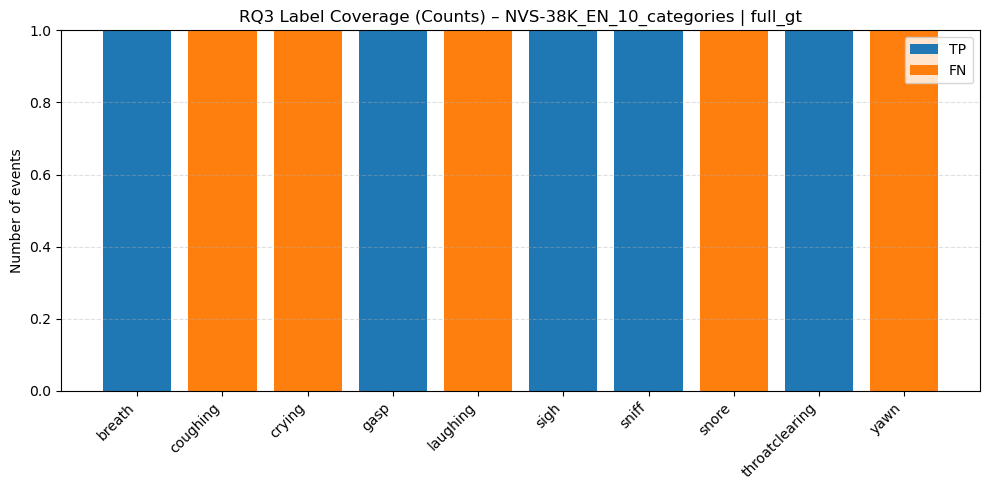

In [40]:
from evaluation.rq_plots import plot_rq3_label_coverage

fig = plot_rq3_label_coverage(
    rq3_full_gt_label_tables["NVS-38K_EN_10_categories | full_gt"],
    setting=None,
)
plt.show()


## RQ3 Label quality (full-GT)

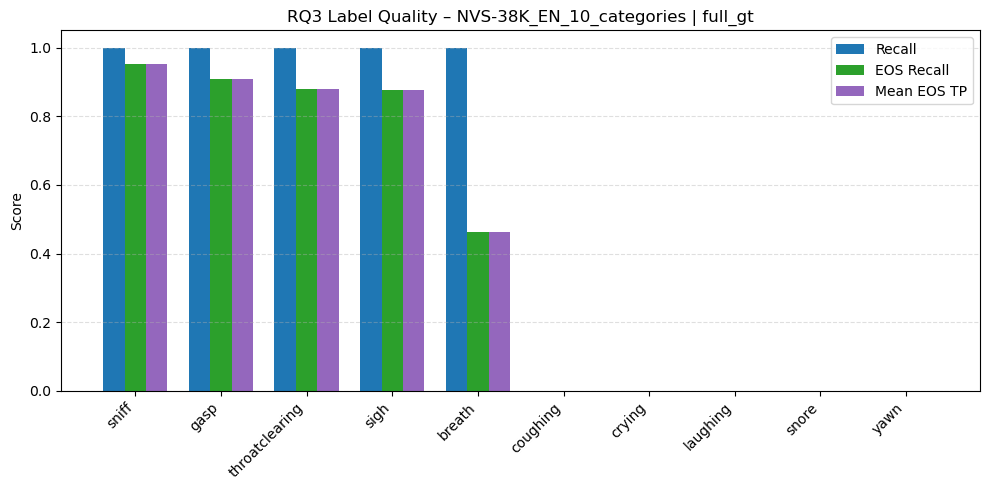

In [41]:
from evaluation.rq_plots import plot_rq3_label_quality

fig = plot_rq3_label_quality(
    rq3_full_gt_label_tables["NVS-38K_EN_10_categories | full_gt"]
)
plt.show()

## RQ3 Global Recall Comparison (Full-GT - Part-GT)

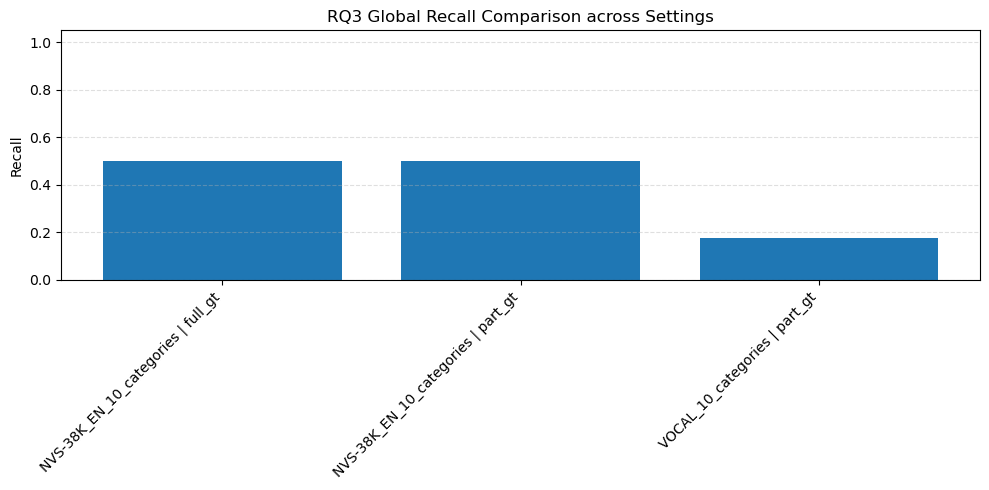

In [42]:
from evaluation.rq_plots import plot_rq3_global_recall_comparison

fig = plot_rq3_global_recall_comparison(
    rq3_global_all,
    setting_order=setting_order,
)
plt.show()

## RQ3 Event Samples (Part-GT) Tables

In [43]:
## RQ3 Event Samples (Part-GT) Tables
print("RQ3 Event Tables (Part-GT):")
for setting_name, df_table in rq3_part_gt_event_tables.items():
    print(f"\n=== {setting_name} ===")
    display(df_table)

RQ3 Event Tables (Part-GT):

=== NVS-38K_EN_10_categories | part_gt ===


,Setting,Audio ID,GT Event ID,GT Label,Cand Event ID,Cand Label,Status,EOS,Overlap (s)
0,NVS-38K_EN_10_categories | part_gt,nvs38k_00007,NVS_EN_000001,sigh,1,non_word (nlp): [UH],Hit,0.877,0.800
1,NVS-38K_EN_10_categories | part_gt,nvs38k_00020,NVS_EN_000002,throatclearing,1,filler (nlp): Hmm.,Hit,0.880,0.627
2,NVS-38K_EN_10_categories | part_gt,nvs38k_00342,NVS_EN_000022,breath,1,filler (nlp): -hmm.,Hit,0.464,0.159
3,NVS-38K_EN_10_categories | part_gt,nvs38k_00443,NVS_EN_000027,sniff,1,filler (nlp): Hmm.,Hit,0.951,0.440
4,NVS-38K_EN_10_categories | part_gt,nvs38k_00493,NVS_EN_000029,gasp,1,filler (nlp): Oh.,Hit,0.909,0.593
5,NVS-38K_EN_10_categories | part_gt,nvs38k_00037,NVS_EN_000004,yawn,<NA>,NaN,Miss,0.000,0.000
6,NVS-38K_EN_10_categories | part_gt,nvs38k_00048,NVS_EN_000005,crying,<NA>,NaN,Miss,0.000,0.000
7,NVS-38K_EN_10_categories | part_gt,nvs38k_00054,NVS_EN_000006,laughing,<NA>,NaN,Miss,0.000,0.000
8,NVS-38K_EN_10_categories | part_gt,nvs38k_00253,NVS_EN_000016,coughing,<NA>,NaN,Miss,0.000,0.000
9,NVS-38K_EN_10_categories | part_gt,nvs38k_03735,NVS_EN_000152,snore,<NA>,NaN,Miss,0.000,0.000



=== VOCAL_10_categories | part_gt ===


,Setting,Audio ID,GT Event ID,GT Label,Cand Event ID,Cand Label,Status,EOS,Overlap (s)
0,VOCAL_10_categories | part_gt,M3QYDtSbhrA,a_RA1_11_02,grunt/sigh/yawn,7,filler (nlp): Yeah.,Hit,0.911,0.601
1,VOCAL_10_categories | part_gt,SPvqSJ5xukI,a_RA1_45_01,gasp,1,filler (nlp): Huh.,Hit,0.933,0.499
2,VOCAL_10_categories | part_gt,SPvqSJ5xukI,a_RA1_45_02,gasp,2,filler (nlp): Huh?,Hit,0.949,0.427
3,VOCAL_10_categories | part_gt,ksYkoXwDOdw,a_RA1_08_02,aijaijai sound,3,oov (nlp): Orchidee,Hit,0.982,1.731
4,VOCAL_10_categories | part_gt,wGGqWwVb3sU,a_RA1_511,laughter,1,nvv (vad_gap),Hit,0.894,1.762
...,...,...,...,...,...,...,...,...,...
75,VOCAL_10_categories | part_gt,wGGqWwVb3sU,NaN,NaN,8,non_word (nlp): [UH],Insertion,NaN,NaN
76,VOCAL_10_categories | part_gt,wGGqWwVb3sU,NaN,NaN,9,filler (nlp): oh,Insertion,NaN,NaN
77,VOCAL_10_categories | part_gt,wGGqWwVb3sU,NaN,NaN,10,non_word (nlp): [UH],Insertion,NaN,NaN
78,VOCAL_10_categories | part_gt,wGGqWwVb3sU,NaN,NaN,11,filler (nlp): oh.,Insertion,NaN,NaN


In [ ]:
display(rq1_tables["full_gt"].columns)
display(rq2a_single_all.columns)
display(rq3_global_tables["full_gt"].columns)

Index(['Setting', 'System', 'F1', 'Recall', 'EOS Recall', 'Mean EOS TP',
       'Insertion Rate'],
      dtype='object')

Index(['setting', 'dataset_name', 'mode', 'combo_key', 'vad_mask',
       'asr_audio_in', 'n_audio_ids', 'macro_mean_n_gt', 'macro_mean_n_cand',
       'macro_mean_tp', 'macro_mean_fn', 'macro_mean_fp', 'macro_mean_recall',
       'macro_mean_precision', 'macro_mean_f1', 'macro_mean_mean_dice_eos_tp',
       'macro_mean_dice_eos_recall', 'macro_mean_mean_overlap_s_tp',
       'macro_mean_insertion_rate', 'macro_mean_deletion_rate',
       'macro_mean_error_rate', 'rank_within_run'],
      dtype='object')

Index(['Setting', 'n_gt_events_total', 'tp_total', 'fn_total',
       'insertions_total', 'F1', 'Recall', 'EOS Recall', 'Mean EOS TP',
       'Insertion Rate', 'Deletion Rate'],
      dtype='object')

| RQ | Experiment | Full-GT Mode | Part-GT Mode | Result |
|---|---|---|---|---|
| RQ1 Capability | Baseline vs. best configuration set | Greedy forward selection + union evaluation (F1-based) | Reuse of selected set + union evaluation | Best achievable score vs. baseline |
| RQ2 Sensitivity | Configuration ranking (single best) | Ranking based on full-GT metrics | Ranking based on part-GT metrics | Best single configuration |
|  | Configuration combination (selected set) | Greedy forward selection + union evaluation | Reuse of selected set + union evaluation | Best-performing configuration set |
|  | Audio derivative aggregation | Group-wise comparison by ASR input audio derivative | Distribution-based comparison across groups | Best-performing audio derivative group |
| RQ3 NVV Coverage | Coverage analysis | Global and label-level analysis | Global and Event-level analysis | Coverage across categories or events |

| RQ | Experiment | Full-GT Mode | Part-GT Mode | Result |
|---|---|---|---|---|
| RQ1 Capability | Compare baseline vs. best configuration set | Baseline evaluation + greedy forward selection (F1-based) with union evaluation | Baseline evaluation + reuse of selected configuration set with union evaluation | Best achievable score of the pipeline vs. baseline |
| RQ2 Sensitivity: Configuration Selection | Single: Rank all configurations; identify best single configuration | Configuration ranking based on full-GT metrics | Configuration ranking based on part-GT metrics | Best single configuration |
|  | Selected Set: Select complementary configurations via greedy forward selection and union | Greedy forward selection (F1-based) + union evaluation | Reuse of selected configuration set + union evaluation | Best-performing configuration set |
| RQ2 Sensitivity: Configuration Component (Audio Derivatives) | Aggregate configurations by ASR input audio derivative | Comparison of configuration performance distributions and best configurations per group | Comparison of configuration performance distributions and best configurations per group | Best-performing audio derivative group |
| RQ3 NVV Coverage | Analyze detected, missed, and inserted NVVs | Global metric-based and label-level analysis using full-GT metrics | Global and Event-level analysis of detected, missed, and inserted events | Coverage per category or event-level coverage representation |